# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

Shape: (28221, 10)

Columns: ['ID', 'OPEID', 'Institution Name', 'City', 'State', 'Foreign Gift Received Date', 'Foreign Gift Amount', 'Gift Type', 'Country of Giftor', 'Giftor Name']
count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


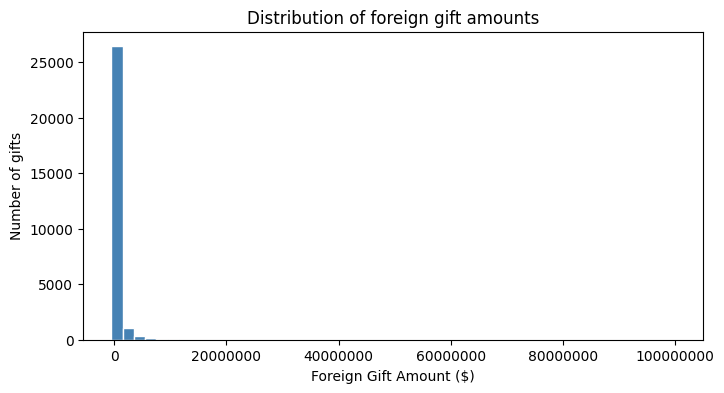

In [ ]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("./data/ForeignGifts_edu.csv")
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.head()
# print(df.isna().sum())

print(df["Foreign Gift Amount"].describe())

plt.figure(figsize=(8, 4))
plt.hist(df["Foreign Gift Amount"], bins=50, color="steelblue", edgecolor="white")
plt.xlabel("Foreign Gift Amount ($)")
plt.ylabel("Number of gifts")
plt.title("Distribution of foreign gift amounts")
plt.ticklabel_format(style="plain")
plt.show()




Gift amounts are wildly lopsided. Almost every gift is fairly ordinary, with the middle of the pack sitting in the thousands to low hundreds of thousands, but a small handful are enormous, and those few carry most of the money. That is why the average comes out many times larger than the typical gift, and why the histogram collapses into one tall bar with a long empty stretch beside it. The scale is being set by a few outliers rather than by the bulk of the data. There are two things worth noting. Some records are zero or negative, which probably means refunds or corrections rather than real gifts, and those may cause trouble when we take logs later. Also, the largest value repeats several times at just under a hundred million, so there may be a cap on the data collection which may influence results more since those donations are actually much larger then. represented in the set. 

Share of gifts under $2M: 0.953
Gift Type
Contract         17274
Monetary Gift    10936
Real Estate         11
Name: count, dtype: int64
Gift Type
Contract         0.6121
Monetary Gift    0.3875
Real Estate      0.0004
Name: proportion, dtype: float64


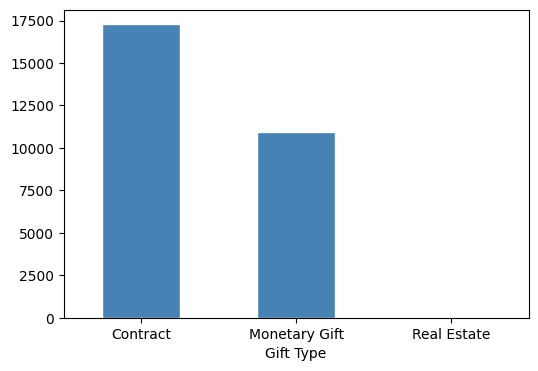

In [10]:
small_gifts = df[df["Foreign Gift Amount"] < 2000000]
print("Share of gifts under $2M:", round(len(small_gifts) / len(df), 3))


counts = df["Gift Type"].value_counts()
print(counts)

proportions = df["Gift Type"].value_counts(normalize=True)
print(proportions.round(4))

plt.figure(figsize=(6, 4))
counts.plot(kind="bar", color="steelblue", edgecolor="white")
plt.xticks(rotation=0)
plt.show()

Rows dropped: 24


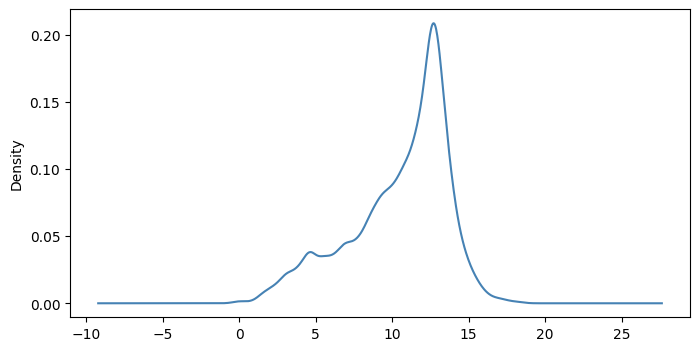

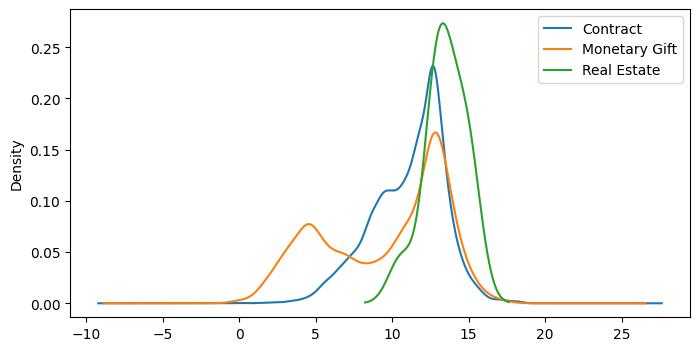

                 count   mean   std    min    25%    50%    75%    max
Gift Type                                                             
Contract       17250.0  11.12  2.39   0.00   9.54  11.61  12.81  18.42
Monetary Gift  10936.0   9.55  4.02   0.00   5.52  10.82  12.90  17.70
Real Estate       11.0  13.48  1.34  10.58  12.82  13.41  14.51  15.28


In [15]:
import scipy
positive = df[df["Foreign Gift Amount"] > 0].copy()
print("Rows dropped:", len(df) - len(positive))

positive["Log Amount"] = np.log(positive["Foreign Gift Amount"])

plt.figure(figsize=(8, 4))
positive["Log Amount"].plot(kind="density", color="steelblue")
plt.show()


plt.figure(figsize=(8, 4))

for gift_type in ["Contract", "Monetary Gift", "Real Estate"]:
    subset = positive[positive["Gift Type"] == gift_type]
    subset["Log Amount"].plot(kind="density", label=gift_type)

plt.legend()
plt.show()

print(positive.groupby("Gift Type")["Log Amount"].describe().round(2))

Taking logs fixes the readability problem immediately. What was a single spike against an empty axis becomes a clear shape with a strong peak around a few hundred thousand dollars. But it is not a clean bell curve. There is a second, smaller hump far down at the low end, around fifty to a few hundred dollars, plus a shoulder in the mid range. That tells us we are not looking at one population of gifts but several kinds of transaction mixed together.

Splitting by type shows what those humps are. The low bump belongs almost entirely to monetary gifts, which makes sense: small individual donations of a hundred dollars are common, while nobody signs a research contract for that amount. Contracts stay clustered fairly tightly around the main peak, since they are negotiated agreements and tend to fall in a predictable band. Gifts are spread much wider and carry that long thin tail of small donations, which is why their average ends up lower even though both types peak in roughly the same place. The real estate curve looks tall and tidy, but it rests on only eleven properties, so its shape is mostly an artifact of the smoothing rather than a finding.

In [21]:
gifts_by_count = df.groupby("Country of Giftor").size()
top_by_count = gifts_by_count.sort_values(ascending=False).head(15)
print(top_by_count)

gifts_by_amount = df.groupby("Country of Giftor")["Foreign Gift Amount"].sum()
top_by_amount = gifts_by_amount.sort_values(ascending=False).head(15)
print(top_by_amount)

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64


In [27]:
by_giftor = df.groupby("Giftor Name")["Foreign Gift Amount"].sum()
top_giftors = by_giftor.sort_values(ascending=False).head(10)
print(top_giftors)

print("\nNumber of distinct named giftors:", df["Giftor Name"].nunique())
print("Rows with no giftor name:", df["Giftor Name"].isna().sum())

Giftor Name
Qatar Foundation                       1166503744
Qatar Foundation/Qatar National Res     796197000
Qatar Foundation for Education          373945215
Anonymous                               338793629
Saudi Arabian Cultural Mission          275221475
HCL                                     190000000
Church of Jesus Christ of LDS           185203715
Emirates Institute for Advanced Sc      170641244
QIC                                     148355497
Anonymous #9                             96334996
Name: Foreign Gift Amount, dtype: int64

Number of distinct named giftors: 8993
Rows with no giftor name: 3751


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [28]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]